In [37]:
import numpy as np
import numba as nb
import yfinance as yf
import pandas as pd

def trend_filter(df: pd.DataFrame,
                 growth_4_min: float = 25.,
                 growth_12_min: float = 50.) -> np.array:
    '''
    Take in a pandas series and output a binary array to indicate if a stock
    fits the growth criteria (1) or not (0)0
    Parameters
    ----------
    prices : pd.core.series.Series
        The prices we are using to check for growth
    growth_4_min : float, optional
        The minimum 4 week growth. The default is 25
    growth_12_min : float, optional
        The minimum 12 week growth. The default is 50
    growth_24_min : float, optional
        The minimum 24 week growth. The default is 80
    Returns
    -------
    np.array
        A binary array showing the positions where the growth criteria is met
    '''
    
    growth_func = lambda x: 100*(x.values[-1]/x.min() - 1)
    
    growth_4 = df['Close'].rolling(10).apply(growth_func) > growth_4_min
    growth_12 = df['Close'].rolling(20).apply(growth_func) > growth_12_min
    
    return np.where(
        growth_4 | growth_12,
        1,
        0,
    )

@nb.jit(nopython = True)
def explicit_heat_smooth(prices: np.array,
                         t_end: float = 5.0) -> np.array:
    '''
    Smoothen out a time series using a explicit finite difference method.
    Parameters
    ----------
    prices : np.array
        The price to smoothen
    t_end : float
        The time at which to terminate the smootheing (i.e. t = 2)
    Returns
    -------
    P : np.array
        The smoothened time-series
    '''
    
    k = 0.01 # Time spacing, must be < 1 for numerical stability
    
    # Set up the initial condition
    P = prices
    
    t = 0
    while t < t_end:
        # Solve the finite difference scheme for the next time-step
        P = k*(P[2:] + P[:-2]) + P[1:-1]*(1-2*k)
        
        # Add the fixed boundary conditions since the above solves the interior
        # points only
        P = np.hstack((
            np.array([prices[0]]),
            P,
            np.array([prices[-1]]),
        ))
        t += k

    return P

        
@nb.jit(nopython = True)
def check_consolidation(prices: np.array,
                        perc_change_min: int,
                        perc_change_thresh: float,
                        check_min: int) -> int:
    '''
    Smoothen the time-series and check for consolidation, see the
    docstring of find_consolidation for the parameters
    '''
    
    # Find the smoothed representation of the time series
    prices = explicit_heat_smooth(prices)

    # Perc change of the smoothed time series to perc_change_min min prior
    perc_change = prices[perc_change_min:]/prices[:-perc_change_min] - 1

    consolidating = np.where(np.abs(perc_change) < perc_change_thresh, 1, 0)
    
    # Provided one entry in the last n min passes the consolidation check,
    # we say that the financial instrument is in consolidation on the end day
    if np.sum(consolidating[-check_min:]) > 0:
        return 1
    else:
        return 0
    
    
@nb.jit(nopython = True)
def find_consolidation(prices: np.array,
                       min_to_smooth: int = 10,
                       perc_change_min: int = 5,
                       perc_change_thresh: float = 0.00015,
                       check_min: int = 5) -> np.array:
    '''
    Return a binary array to indicate whether each of the data-points are
    classed as consolidating or not
    Parameters
    ----------
    prices : np.array
        The price time series to check for consolidation
    min_to_smooth : int, optional
        The length of the time-series to smoothen (min). The default is 50.
    perc_change_min : int, optional
        The min back to % change compare against (min). The default is 5.
    perc_change_thresh : float, optional
        The range trading % criteria for consolidation. The default is 0.015.
    check_min : int, optional
        This says the number of lookback min to check for any consolidation.
        If any min in check_min back is consolidating, then the last data
        point is said to be consolidating. The default is 5.
    Returns
    -------
    res : np.array
        The binary array indicating consolidation (1) or not (0)
    '''
    
    res = np.full(prices.shape, np.nan)
    
    for idx in range(min_to_smooth, prices.shape[0]):
        res[idx] = check_consolidation(
            prices = prices[idx-min_to_smooth:idx],
            perc_change_min = perc_change_min,
            perc_change_thresh = perc_change_thresh,
            check_min = check_min,
        )
        
    return res
    

if __name__ == '__main__':

    ticker= yf.Ticker("AAPL")
    df = ticker.history(start="2024-09-17", end="2024-09-19", interval="5m")

    '''
    prices = explicit_heat_smooth(df['Close'].values)
    df = pd.DataFrame(prices)
    df.to_csv("prices.csv")
    '''

    '''
    df.loc[:, 'datetime'] = df.index
    df.loc[:, 'consolidating'] = find_consolidation(df['Close'].values)
    df.dropna()
    '''

    df.loc[:, 'datetime'] = df.index
    df.loc[:, 'consolidating'] = find_consolidation(df['Close'].values)
    df.loc[:, 'trend_filter'] = trend_filter(df)
    df.loc[:, 'filtered'] = np.where(df['consolidating'] == 1, True, False)
    
    #df.to_csv('smoothing5min.csv', index=False)

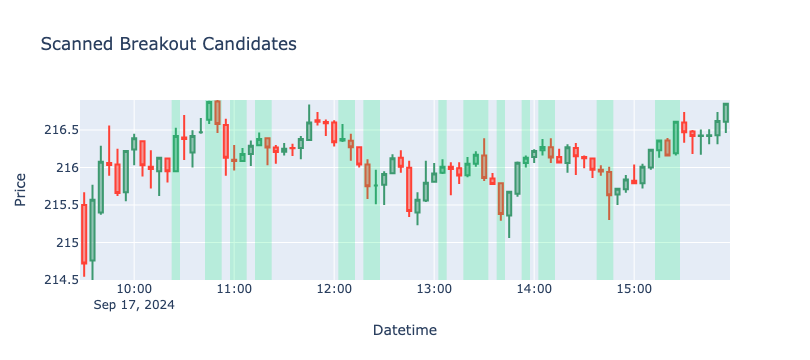

In [41]:
import plotly.io as pio
import plotly.graph_objects as go  
    
df = df[(df.index > '2024-09-17') & (df.index  < '2024-09-19')]

df['bar_plot'] = np.where(
    df['filtered'],
    df['High'].max(),
    df['Low'].min(),
)

fig = go.Figure()

fig.add_trace(
    go.Candlestick(
        x = df.index,
        open = df['Open'], 
        high = df['High'],
        low = df['Low'],
        close = df['Close'],
        showlegend = False,
    ),
)

fig.add_trace(
    go.Scatter(
        x = df.index, 
        y = df['bar_plot'],
        fill = 'tonexty',
        fillcolor = 'rgba(0, 236, 109, 0.2)',
        mode = 'lines',
        line = {'width': 0, 'shape': 'hvh'},
        showlegend = False,
    ),
)

fig.update_layout(
    xaxis = {'title': 'Datetime'},
    yaxis = {'range': [df['Low'].min(), df['High'].max()], 'title': 'Price'},
    title = 'Scanned Breakout Candidates'
)

fig.update_xaxes(
    rangebreaks = [{'bounds': ['sat', 'mon']}],
    rangeslider_visible = False,
)

fig.show()